In [1]:
import json
import pandas as pd

In [2]:
# Load the uploaded JSON file
with open("1512772.json", "r") as f:
    match_data = json.load(f)

In [3]:
# Extract innings
innings_data = match_data["innings"]

In [4]:
# Collect ball-by-ball records
records = []
for inn in innings_data:
    team = inn["team"]
    for over in inn["overs"]:
        over_num = over["over"]
        for delivery in over["deliveries"]:
            record = {
                "team": team,
                "over": over_num,
                "batter": delivery.get("batter"),
                "bowler": delivery.get("bowler"),
                "non_striker": delivery.get("non_striker"),
                "runs_batter": delivery["runs"]["batter"],
                "runs_extras": delivery["runs"]["extras"],
                "runs_total": delivery["runs"]["total"],
                "wicket": delivery.get("wickets", None)
            }
            records.append(record)

# Convert to DataFrame
df = pd.DataFrame(records)

# --- Analytics ---
# Total runs per batter
runs_per_batter = df.groupby("batter")["runs_batter"].sum().sort_values(ascending=False)

# Runs conceded per bowler
runs_per_bowler = df.groupby("bowler")["runs_total"].sum().sort_values(ascending=False)

# Wickets summary
wickets = df[df["wicket"].notnull()][["bowler","wicket"]]

# Over-by-over score progression
over_progression = df.groupby("over")["runs_total"].sum().cumsum()

# Display results
print("Runs per batter:\n", runs_per_batter)
print("\nRuns conceded per bowler:\n", runs_per_bowler)
print("\nWickets:\n", wickets)
print("\nScore progression:\n", over_progression)

Runs per batter:
 batter
JG Bethell         105
SV Samson           89
S Dube              43
Ishan Kishan        39
WG Jacks            35
HH Pandya           27
JC Buttler          25
Tilak Varma         21
JC Archer           19
SM Curran           18
T Banton            17
SA Yadav            11
Abhishek Sharma      9
HC Brook             7
PD Salt              5
J Overton            2
AR Patel             2
CV Varun             0
Name: runs_batter, dtype: int64

Runs conceded per bowler:
 bowler
CV Varun          64
JC Archer         61
SM Curran         54
Arshdeep Singh    51
WG Jacks          42
AU Rashid         41
HH Pandya         39
AR Patel          37
J Overton         36
JJ Bumrah         33
S Dube            22
LA Dawson         19
Name: runs_total, dtype: int64

Wickets:
              bowler                                             wicket
11         WG Jacks  [{'player_out': 'Abhishek Sharma', 'fielders':...
59        AU Rashid  [{'player_out': 'Ishan Kishan', 'fiel

In [5]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load JSON file
with open("1512772.json", "r") as f:
    match_data = json.load(f)

innings_data = match_data["innings"]

C:\Users\bhara\AppData\Local\Temp\ipykernel_29888\3151873199.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=runs_per_batter.index, y=runs_per_batter.values, palette="Blues_d")


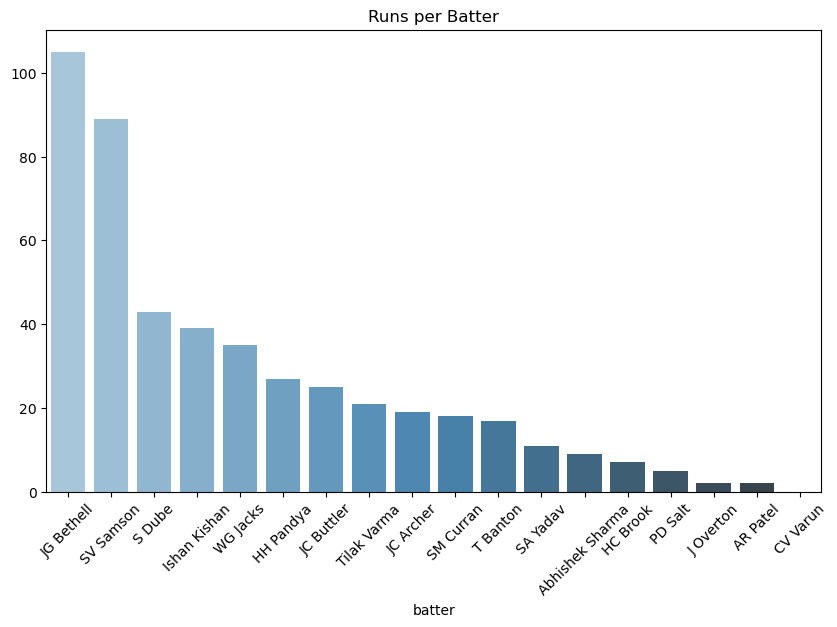

C:\Users\bhara\AppData\Local\Temp\ipykernel_29888\3151873199.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=runs_per_bowler.index, y=runs_per_bowler.values, palette="Reds_d")


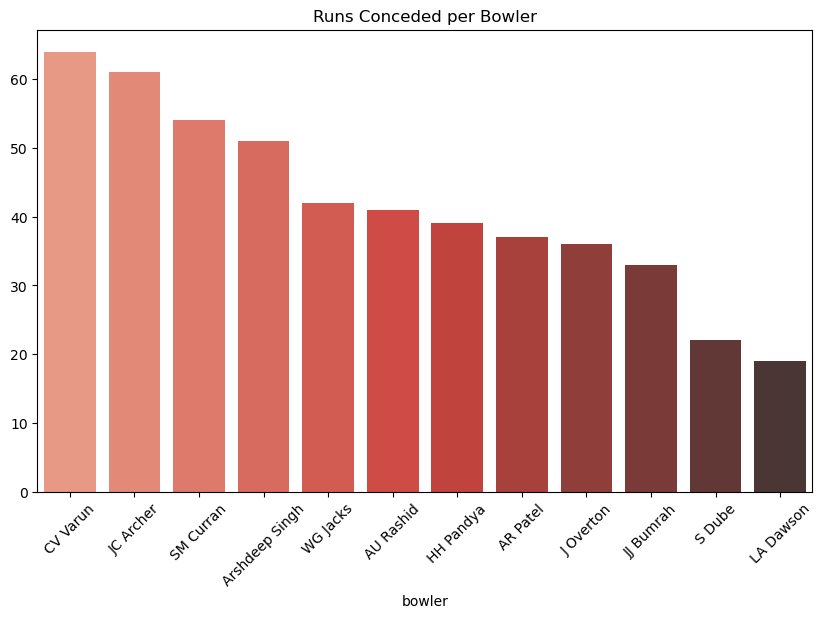

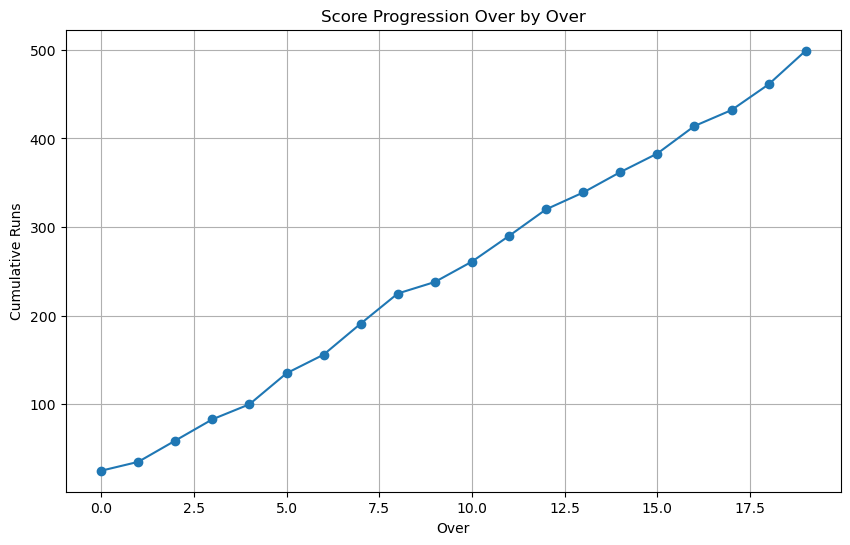


Wickets Summary (Player Out, Bowler, Kind, Score at Dismissal):

          player_out     kind          bowler  score_at_dismissal
11   Abhishek Sharma   caught        WG Jacks                  20
59      Ishan Kishan   caught       AU Rashid                 117
83         SV Samson   caught        WG Jacks                 160
100         SA Yadav  stumped       AU Rashid                 190
111           S Dube  run out       SM Curran                 212
121      Tilak Varma   bowled       JC Archer                 236
127        HH Pandya  run out        WG Jacks                 251
135          PD Salt   caught       HH Pandya                 266
153         HC Brook   caught       JJ Bumrah                 291
163       JC Buttler   bowled        CV Varun                 317
174         T Banton   bowled        AR Patel                 348
218         WG Jacks   caught  Arshdeep Singh                 425
248        SM Curran   caught       HH Pandya                 475
252       

In [6]:
records = []
score = 0  # running total to track score at dismissal

for inn in innings_data:
    team = inn["team"]
    for over in inn["overs"]:
        over_num = over["over"]
        for delivery in over["deliveries"]:
            runs = delivery["runs"]["total"]
            score += runs
            record = {
                "team": team,
                "over": over_num,
                "batter": delivery.get("batter"),
                "bowler": delivery.get("bowler"),
                "runs_batter": delivery["runs"]["batter"],
                "runs_extras": delivery["runs"]["extras"],
                "runs_total": runs,
                "wicket": None,
                "score_at_ball": score
            }
            if "wickets" in delivery:
                for w in delivery["wickets"]:
                    record["wicket"] = {
                        "player_out": w["player_out"],
                        "kind": w["kind"],
                        "bowler": delivery.get("bowler"),
                        "score_at_dismissal": score
                    }
            records.append(record)

df = pd.DataFrame(records)

# --- Analytics ---
# Runs per batter
runs_per_batter = df.groupby("batter")["runs_batter"].sum().sort_values(ascending=False)

# Runs conceded per bowler
runs_per_bowler = df.groupby("bowler")["runs_total"].sum().sort_values(ascending=False)

# Wickets summary with score at dismissal
wickets_summary = df[df["wicket"].notnull()]["wicket"].dropna().apply(pd.Series)

# Over-by-over progression
over_progression = df.groupby("over")["runs_total"].sum().cumsum()

# --- Visualizations ---
plt.figure(figsize=(10,6))
sns.barplot(x=runs_per_batter.index, y=runs_per_batter.values, palette="Blues_d")
plt.title("Runs per Batter")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(x=runs_per_bowler.index, y=runs_per_bowler.values, palette="Reds_d")
plt.title("Runs Conceded per Bowler")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,6))
over_progression.plot(marker="o")
plt.title("Score Progression Over by Over")
plt.xlabel("Over")
plt.ylabel("Cumulative Runs")
plt.grid(True)
plt.show()

# Display wickets summary
print("\nWickets Summary (Player Out, Bowler, Kind, Score at Dismissal):\n")
print(wickets_summary)

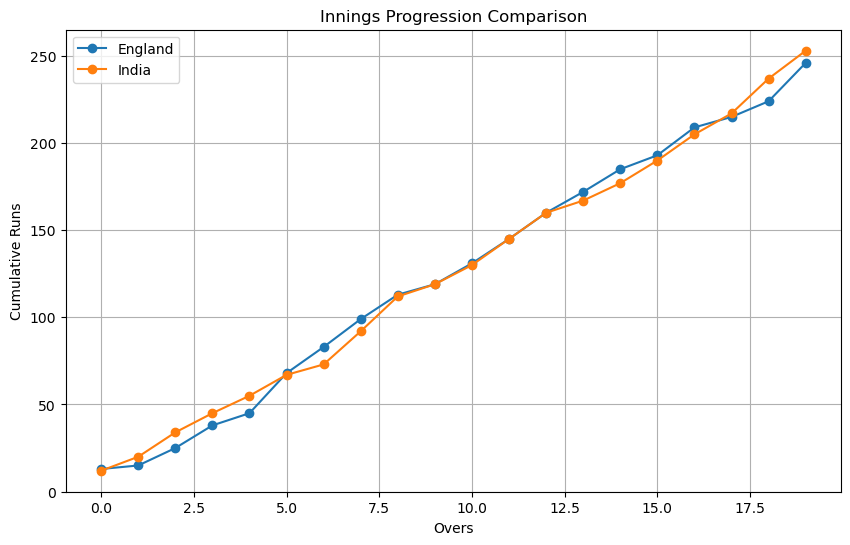


Wickets Summary:
           player_out     kind          bowler  score_at_dismissal
11   Abhishek Sharma   caught        WG Jacks                  20
59      Ishan Kishan   caught       AU Rashid                 117
83         SV Samson   caught        WG Jacks                 160
100         SA Yadav  stumped       AU Rashid                 190
111           S Dube  run out       SM Curran                 212
121      Tilak Varma   bowled       JC Archer                 236
127        HH Pandya  run out        WG Jacks                 251
135          PD Salt   caught       HH Pandya                 266
153         HC Brook   caught       JJ Bumrah                 291
163       JC Buttler   bowled        CV Varun                 317
174         T Banton   bowled        AR Patel                 348
218         WG Jacks   caught  Arshdeep Singh                 425
248        SM Curran   caught       HH Pandya                 475
252       JG Bethell  run out          S Dube            

In [7]:
# --- Scorecards ---
scorecard_batters = df.groupby(["team","batter"])["runs_batter"].sum().reset_index()
scorecard_bowlers = df.groupby(["team","bowler"])["runs_total"].sum().reset_index()

# --- Innings progression ---
progression = df.groupby(["team","over"])["runs_total"].sum().groupby(level=0).cumsum().reset_index()

# --- Plot progression comparison ---
plt.figure(figsize=(10,6))
for team in progression["team"].unique():
    team_data = progression[progression["team"]==team]
    plt.plot(team_data["over"], team_data["runs_total"], marker="o", label=team)

plt.title("Innings Progression Comparison")
plt.xlabel("Overs")
plt.ylabel("Cumulative Runs")
plt.legend()
plt.grid(True)
plt.show()

# --- Wickets summary ---
wickets_summary = df[df["wicket"].notnull()]["wicket"].dropna().apply(pd.Series)
print("\nWickets Summary:\n", wickets_summary)

# --- Scorecards ---
print("\nBatting Scorecard:\n", scorecard_batters)
print("\nBowling Scorecard:\n", scorecard_bowlers)

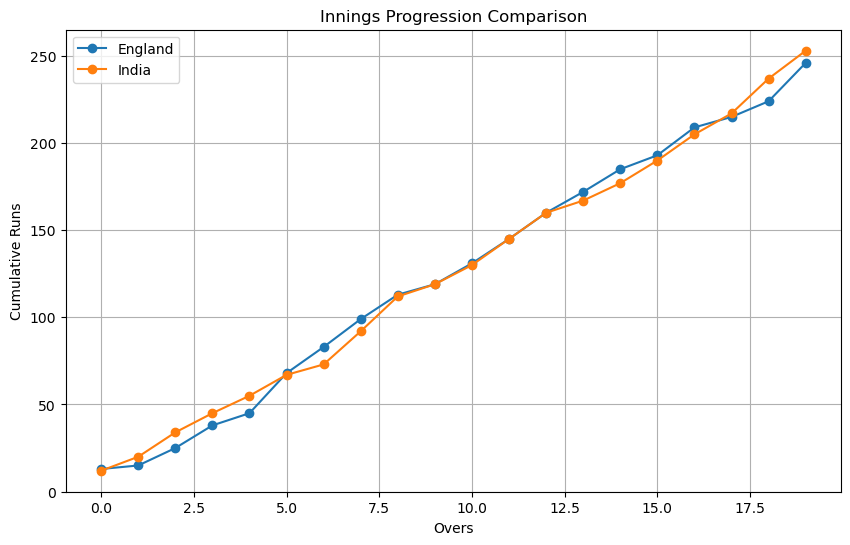


Batting Scorecard Comparison:
 team             England  India
batter                         
AR Patel             0.0    2.0
Abhishek Sharma      0.0    9.0
CV Varun             0.0    0.0
HC Brook             7.0    0.0
HH Pandya            0.0   27.0
Ishan Kishan         0.0   39.0
J Overton            2.0    0.0
JC Archer           19.0    0.0
JC Buttler          25.0    0.0
JG Bethell         105.0    0.0
PD Salt              5.0    0.0
S Dube               0.0   43.0
SA Yadav             0.0   11.0
SM Curran           18.0    0.0
SV Samson            0.0   89.0
T Banton            17.0    0.0
Tilak Varma          0.0   21.0
WG Jacks            35.0    0.0

Bowling Scorecard Comparison:
 team            England  India
bowler                        
AR Patel           37.0    0.0
AU Rashid           0.0   41.0
Arshdeep Singh     51.0    0.0
CV Varun           64.0    0.0
HH Pandya          39.0    0.0
J Overton           0.0   36.0
JC Archer           0.0   61.0
JJ Bumrah        

In [8]:
# --- Batting Scorecards ---
batting_scorecard = df.groupby(["team","batter"])["runs_batter"].sum().reset_index()

# --- Bowling Scorecards ---
bowling_scorecard = df.groupby(["team","bowler"])["runs_total"].sum().reset_index()

# --- Innings Progression ---
progression = df.groupby(["team","over"])["runs_total"].sum().groupby(level=0).cumsum().reset_index()

# --- Side-by-side batting comparison ---
batting_pivot = batting_scorecard.pivot(index="batter", columns="team", values="runs_batter").fillna(0)

# --- Side-by-side bowling comparison ---
bowling_pivot = bowling_scorecard.pivot(index="bowler", columns="team", values="runs_total").fillna(0)

# --- Plot innings progression comparison ---
plt.figure(figsize=(10,6))
for team in progression["team"].unique():
    team_data = progression[progression["team"]==team]
    plt.plot(team_data["over"], team_data["runs_total"], marker="o", label=team)

plt.title("Innings Progression Comparison")
plt.xlabel("Overs")
plt.ylabel("Cumulative Runs")
plt.legend()
plt.grid(True)
plt.show()

# --- Display tables ---
print("\nBatting Scorecard Comparison:\n", batting_pivot)
print("\nBowling Scorecard Comparison:\n", bowling_pivot)

In [9]:
# --- Strike Rate for Batters ---
# Strike Rate = (Runs Scored / Balls Faced) * 100
balls_faced = df.groupby(["team","batter"]).size().reset_index(name="balls_faced")
batting_stats = batting_scorecard.merge(balls_faced, on=["team","batter"])
batting_stats["strike_rate"] = (batting_stats["runs_batter"] / batting_stats["balls_faced"]) * 100

batting_pivot_full = batting_stats.pivot(index="batter", columns="team", values=["runs_batter","balls_faced","strike_rate"]).fillna(0)

# --- Economy Rate for Bowlers ---
# Economy = Runs Conceded / Overs Bowled
balls_bowled = df.groupby(["team","bowler"]).size().reset_index(name="balls_bowled")
bowling_stats = bowling_scorecard.merge(balls_bowled, on=["team","bowler"])
bowling_stats["overs_bowled"] = bowling_stats["balls_bowled"] / 6
bowling_stats["economy_rate"] = bowling_stats["runs_total"] / bowling_stats["overs_bowled"]

bowling_pivot_full = bowling_stats.pivot(index="bowler", columns="team", values=["runs_total","balls_bowled","overs_bowled","economy_rate"]).fillna(0)

# --- Display enhanced tables ---
print("\nEnhanced Batting Scorecard (Runs, Balls, Strike Rate):\n", batting_pivot_full)
print("\nEnhanced Bowling Scorecard (Runs Conceded, Balls, Overs, Economy):\n", bowling_pivot_full)


Enhanced Batting Scorecard (Runs, Balls, Strike Rate):
                 runs_batter       balls_faced       strike_rate            
team                England India     England India     England       India
batter                                                                     
AR Patel                0.0   2.0         0.0   2.0    0.000000  100.000000
Abhishek Sharma         0.0   9.0         0.0   7.0    0.000000  128.571429
CV Varun                0.0   0.0         0.0   1.0    0.000000    0.000000
HC Brook                7.0   0.0         6.0   0.0  116.666667    0.000000
HH Pandya               0.0  27.0         0.0  12.0    0.000000  225.000000
Ishan Kishan            0.0  39.0         0.0  20.0    0.000000  195.000000
J Overton               2.0   0.0         3.0   0.0   66.666667    0.000000
JC Archer              19.0   0.0         5.0   0.0  380.000000    0.000000
JC Buttler             25.0   0.0        17.0   0.0  147.058824    0.000000
JG Bethell            105.0   0

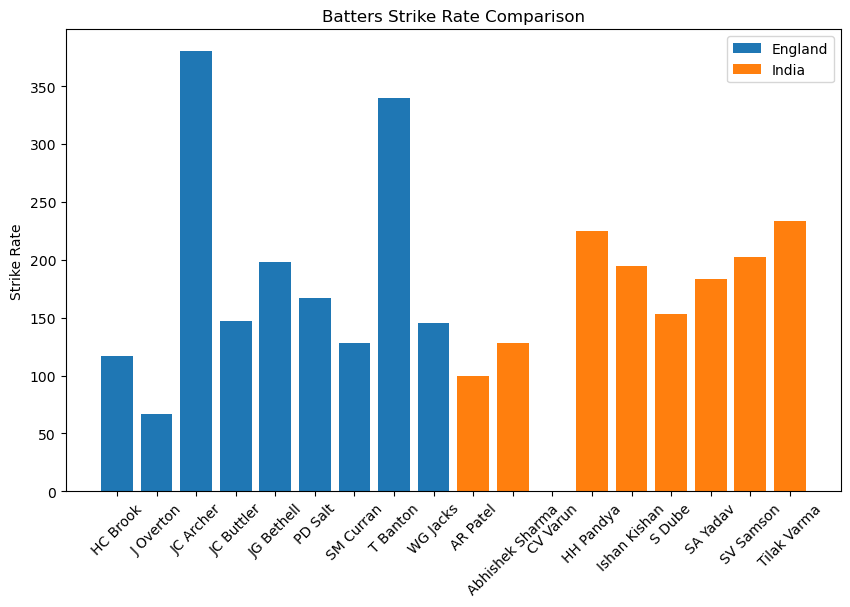

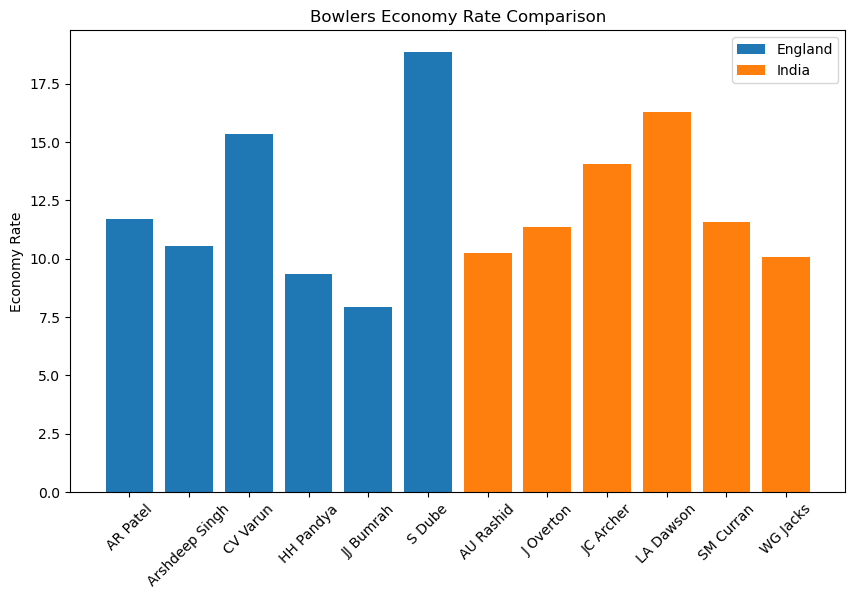

In [10]:
# --- Strike Rate Visualization ---
plt.figure(figsize=(10,6))
for team in batting_stats["team"].unique():
    team_data = batting_stats[batting_stats["team"]==team]
    plt.bar(team_data["batter"], team_data["strike_rate"], label=team)

plt.title("Batters Strike Rate Comparison")
plt.ylabel("Strike Rate")
plt.xticks(rotation=45)
plt.legend()
plt.show()

# --- Economy Rate Visualization ---
plt.figure(figsize=(10,6))
for team in bowling_stats["team"].unique():
    team_data = bowling_stats[bowling_stats["team"]==team]
    plt.bar(team_data["bowler"], team_data["economy_rate"], label=team)

plt.title("Bowlers Economy Rate Comparison")
plt.ylabel("Economy Rate")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [11]:
# --- Partnership Analysis (fixed with proper batter tracking) ---
partnerships = []

for inn in innings_data:
    team = inn["team"]
    current_pair = []
    current_runs = 0
    
    for over in inn["overs"]:
        for delivery in over["deliveries"]:
            batter = delivery.get("batter")
            non_striker = delivery.get("non_striker")
            runs = delivery["runs"]["total"]
            current_runs += runs
            
            # Initialize batting pair if empty
            if not current_pair:
                current_pair = [batter, non_striker]
            
            # If wicket falls, record partnership
            if "wickets" in delivery:
                partnerships.append({
                    "team": team,
                    "pair": f"{current_pair[0]} & {current_pair[1]}",
                    "runs": current_runs,
                    "dismissed": delivery["wickets"][0]["player_out"],
                    "bowler": delivery.get("bowler")
                })
                
                # Reset for next partnership: replace dismissed batter with new striker
                dismissed = delivery["wickets"][0]["player_out"]
                if dismissed == current_pair[0]:
                    current_pair[0] = None  # striker out
                else:
                    current_pair[1] = None  # non-striker out
                current_runs = 0
            
            # Update current pair with latest batter/non-striker info
            current_pair = [batter, non_striker]
    
    # End of innings: record last partnership if runs > 0
    if current_runs > 0 and current_pair:
        partnerships.append({
            "team": team,
            "pair": f"{current_pair[0]} & {current_pair[1]}",
            "runs": current_runs,
            "dismissed": None,
            "bowler": None
        })

# Convert to DataFrame
partnerships_df = pd.DataFrame(partnerships)

# Separate by team
india_partnerships = partnerships_df[partnerships_df["team"]=="India"].reset_index(drop=True)
england_partnerships = partnerships_df[partnerships_df["team"]=="England"].reset_index(drop=True)

print("\nIndia Partnerships:\n", india_partnerships)
print("\nEngland Partnerships:\n", england_partnerships)



India Partnerships:
     team                         pair  runs        dismissed     bowler
0  India  Abhishek Sharma & SV Samson    20  Abhishek Sharma   WG Jacks
1  India     Ishan Kishan & SV Samson    97     Ishan Kishan  AU Rashid
2  India           SV Samson & S Dube    43        SV Samson   WG Jacks
3  India            SA Yadav & S Dube    30         SA Yadav  AU Rashid
4  India           S Dube & HH Pandya    22           S Dube  SM Curran
5  India      Tilak Varma & HH Pandya    24      Tilak Varma  JC Archer
6  India         HH Pandya & AR Patel    15        HH Pandya   WG Jacks
7  India          CV Varun & AR Patel     2             None       None

England Partnerships:
       team                     pair  runs   dismissed          bowler
0  England     JC Buttler & PD Salt    13     PD Salt       HH Pandya
1  England    JC Buttler & HC Brook    25    HC Brook       JJ Bumrah
2  England  JG Bethell & JC Buttler    26  JC Buttler        CV Varun
3  England    T Banton & J

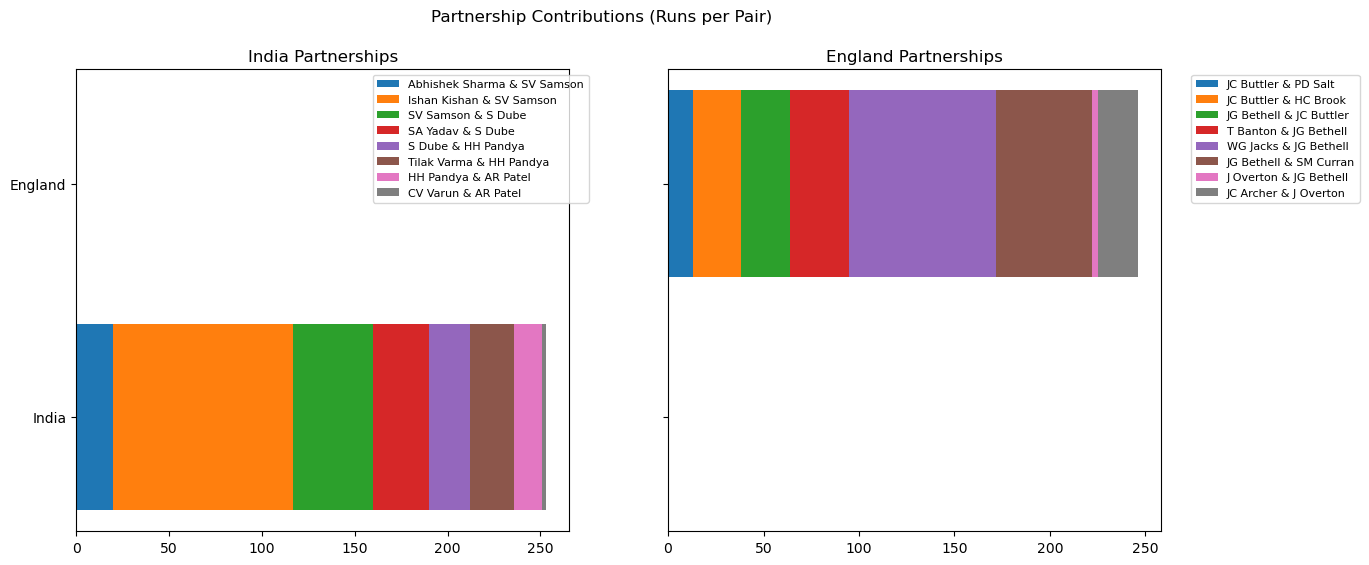

In [12]:
import matplotlib.pyplot as plt

# --- Partnership Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)

# India partnerships stacked bar
india_runs = india_partnerships["runs"].values
india_labels = india_partnerships["pair"].values
axes[0].barh("India", india_runs.sum(), color="lightblue")
bottom = 0
for runs, label in zip(india_runs, india_labels):
    axes[0].barh("India", runs, left=bottom, label=label)
    bottom += runs
axes[0].set_title("India Partnerships")
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper right', fontsize=8)

# England partnerships stacked bar
eng_runs = england_partnerships["runs"].values
eng_labels = england_partnerships["pair"].values
axes[1].barh("England", eng_runs.sum(), color="lightcoral")
bottom = 0
for runs, label in zip(eng_runs, eng_labels):
    axes[1].barh("England", runs, left=bottom, label=label)
    bottom += runs
axes[1].set_title("England Partnerships")
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.suptitle("Partnership Contributions (Runs per Pair)")
plt.show()

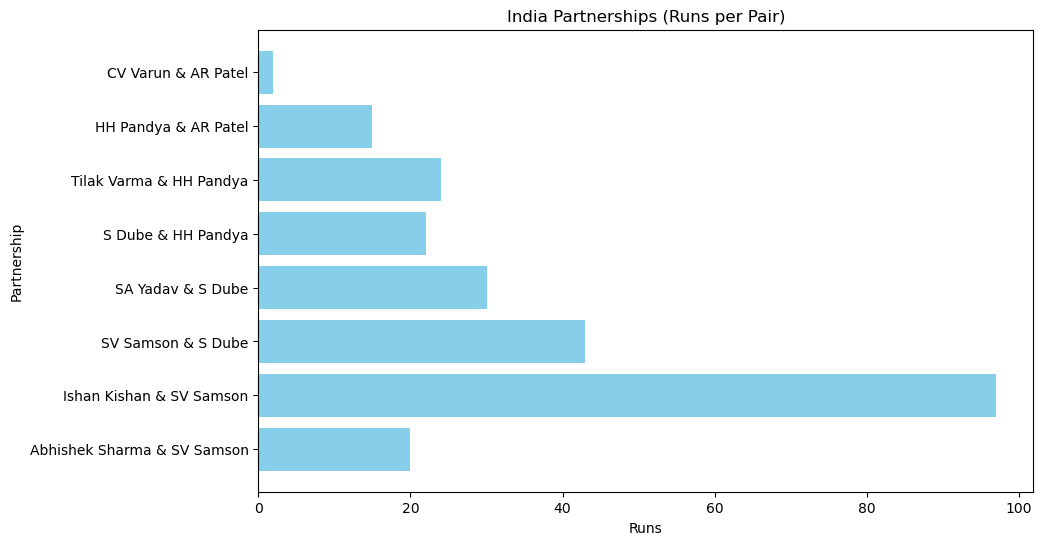

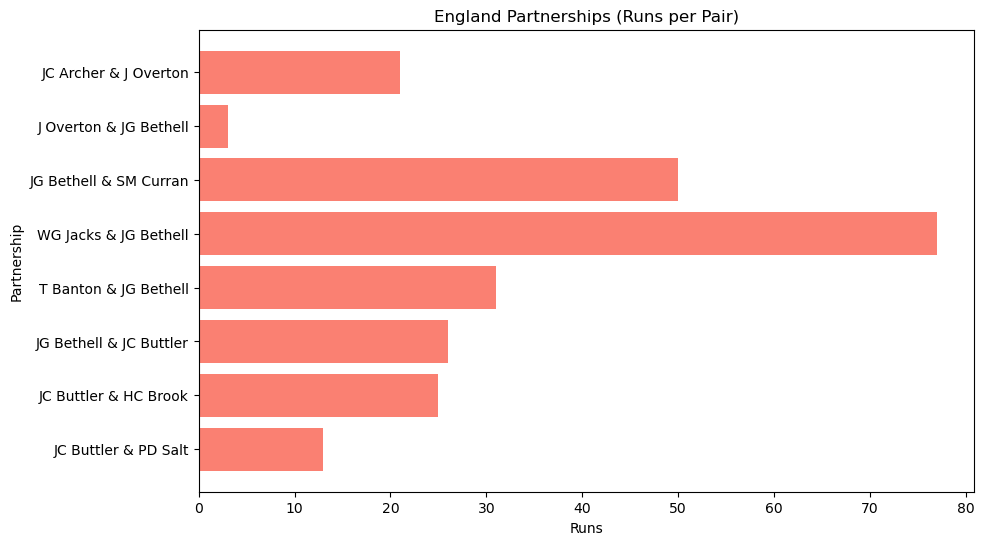

In [13]:
# Partnership bar chart for India
plt.figure(figsize=(10,6))
plt.barh(india_partnerships["pair"], india_partnerships["runs"], color="skyblue")
plt.title("India Partnerships (Runs per Pair)")
plt.xlabel("Runs")
plt.ylabel("Partnership")
plt.show()

# Partnership bar chart for England
plt.figure(figsize=(10,6))
plt.barh(england_partnerships["pair"], england_partnerships["runs"], color="salmon")
plt.title("England Partnerships (Runs per Pair)")
plt.xlabel("Runs")
plt.ylabel("Partnership")
plt.show()

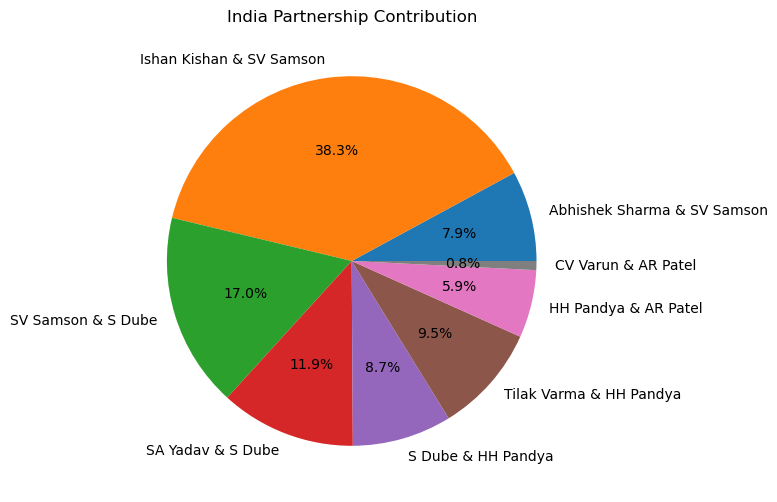

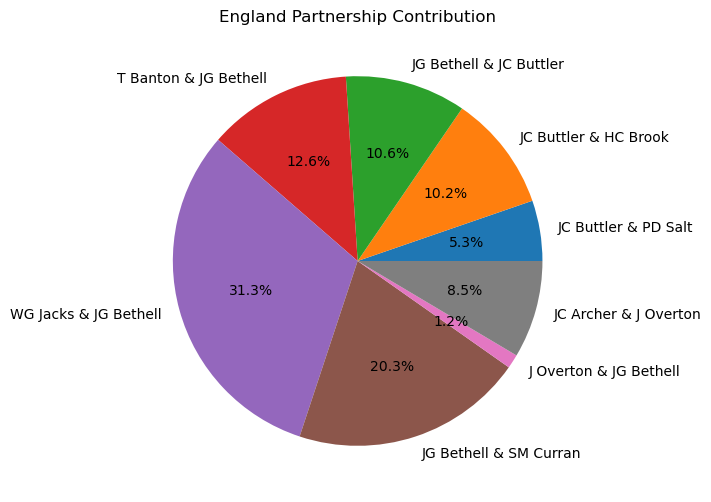

In [14]:
# Pie chart for India
plt.figure(figsize=(6,6))
plt.pie(india_partnerships["runs"], labels=india_partnerships["pair"], autopct="%1.1f%%")
plt.title("India Partnership Contribution")
plt.show()

# Pie chart for England
plt.figure(figsize=(6,6))
plt.pie(england_partnerships["runs"], labels=england_partnerships["pair"], autopct="%1.1f%%")
plt.title("England Partnership Contribution")
plt.show()

In [15]:
import pandas as pd

batters = pd.read_csv("pbi_batters_1512772.csv")

# Simple impact score: runs + (strike_rate/100) + wickets*20 - economy
batters["impact_score"] = batters["runs"] + (batters["strike_rate"]/100) + (batters["outs"]*-5)

print("\nTop Player Impact Scores:\n", batters.sort_values("impact_score", ascending=False).head())


Top Player Impact Scores:
     match_id batting_team        batter  runs  balls  fours  sixes  \
4    1512772      England    JG Bethell   105     48      8      7   
16   1512772        India     SV Samson    89     42      8      7   
14   1512772        India        S Dube    43     25      1      4   
13   1512772        India  Ishan Kishan    39     18      4      2   
8    1512772      England      WG Jacks    35     20      4      2   

    dots_faced  outs  strike_rate  impact_score  
4            8     1   218.750000    102.187500  
16          12     1   211.904762     86.119048  
14           5     1   172.000000     39.720000  
13           3     1   216.666667     36.166667  
8            6     1   175.000000     31.750000  


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

kpi = pd.read_csv("pbi_inn_kpi_1512772.csv")

# Features: runs, wickets, run_rate, boundary_pct, dot_pct
X = kpi[["runs","wickets","run_rate","boundary_pct","dot_pct"]]
y = [1,0]  # India won (1), England lost (0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression()
model.fit(X_scaled, y)

# Forecast India’s chance next game (using India’s semi-final stats)
india_features = X_scaled[0].reshape(1,-1)
prob_win = model.predict_proba(india_features)[0][1]

print("India’s forecasted chance to win next game:", round(prob_win*100,2), "%")

India’s forecasted chance to win next game: 81.48 %


In [17]:
top_batter = batters[batters["batting_team"]=="India"].sort_values("strike_rate", ascending=False).iloc[0]
print(f"Player to watch: {top_batter['batter']} with SR {round(top_batter['strike_rate'],1)}")

Player to watch: Tilak Varma with SR 300.0


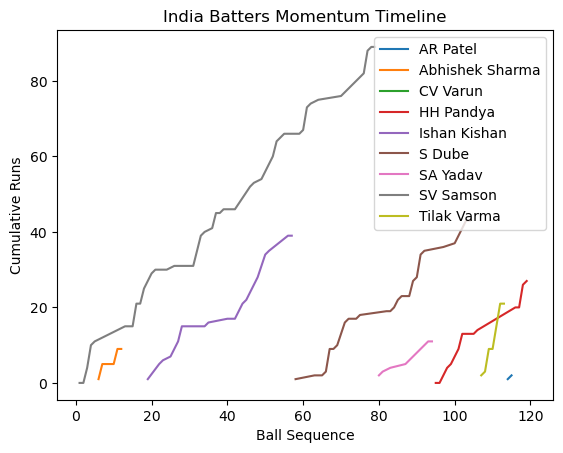

In [18]:
timeline = pd.read_csv("pbi_batter_timeline_1512772.csv")

india_timeline = timeline[timeline["batting_team"]=="India"]
for batter in india_timeline["batter"].unique():
    b_data = india_timeline[india_timeline["batter"]==batter]
    plt.plot(b_data["legal_ball_seq"], b_data["batter_cum_runs"], label=batter)

plt.title("India Batters Momentum Timeline")
plt.xlabel("Ball Sequence")
plt.ylabel("Cumulative Runs")
plt.legend()
plt.show

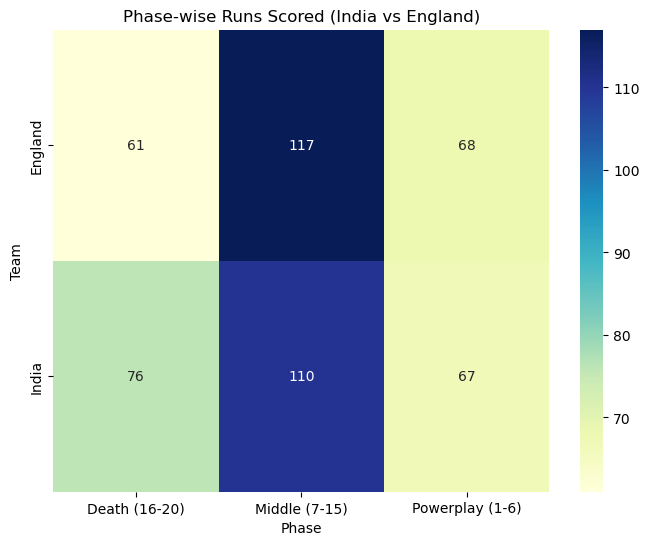

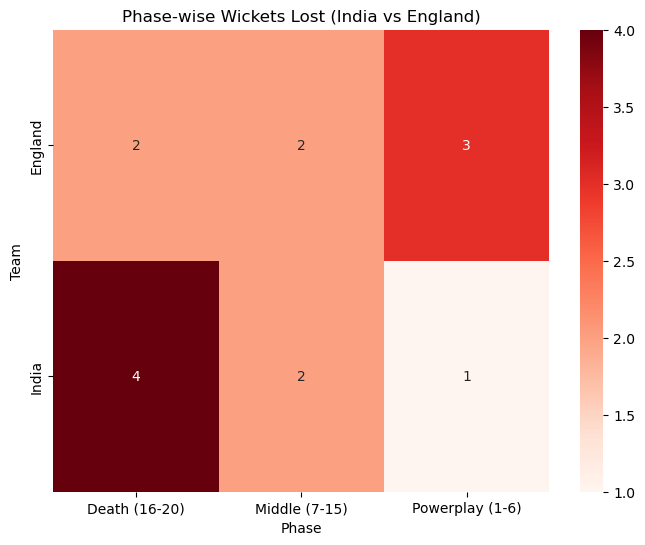

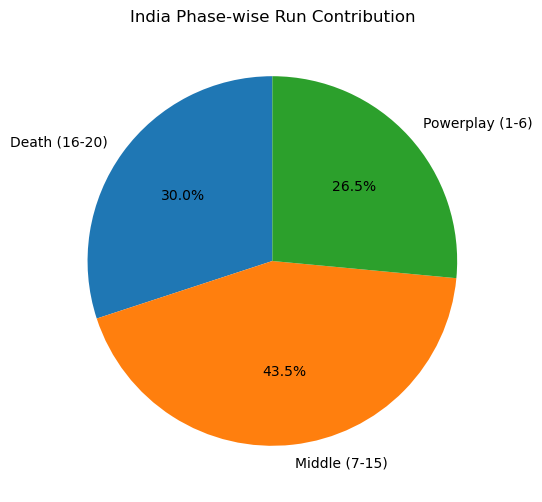

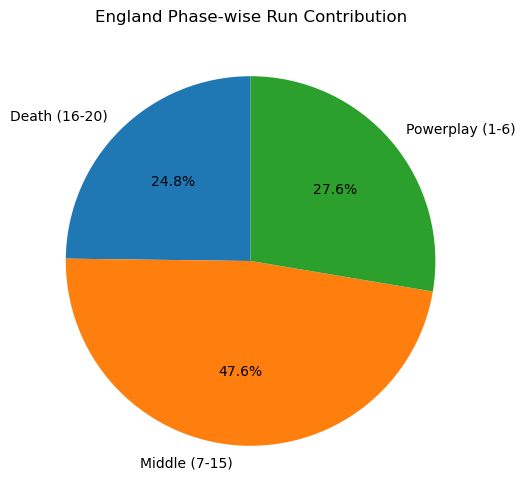

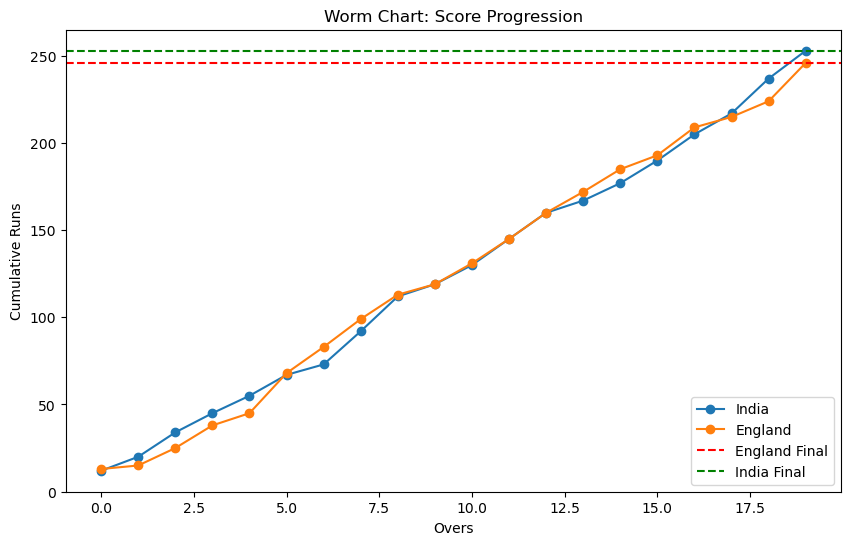

C:\Users\bhara\AppData\Local\Temp\ipykernel_29888\4033014523.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="runs", y="batter", data=top_batters, palette="Blues_r")


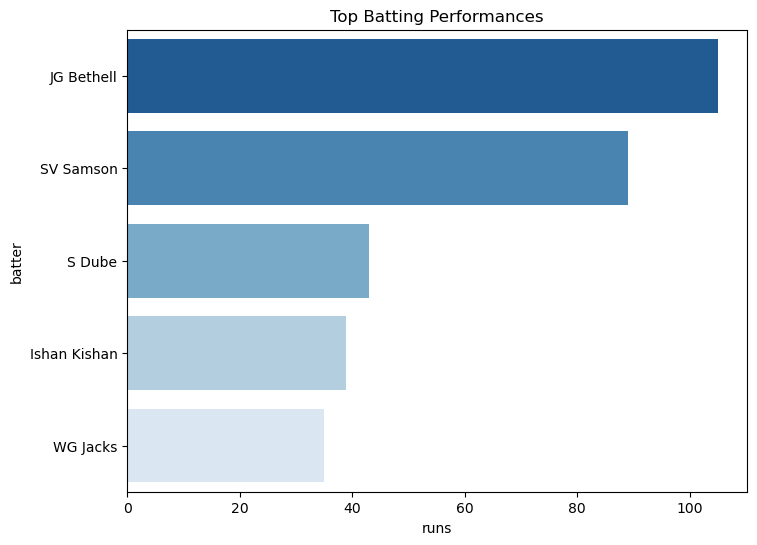

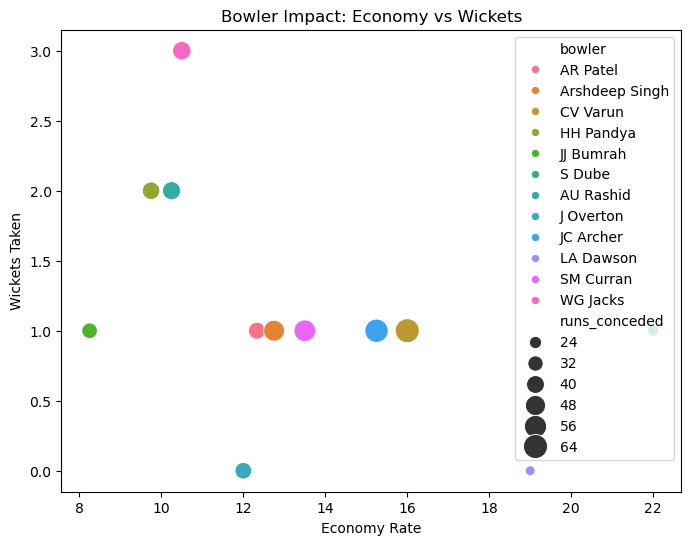

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load CSVs ---
phases = pd.read_csv("pbi_phases_1512772.csv")
overs = pd.read_csv("pbi_overs_1512772.csv")
worm = pd.read_csv("pbi_worm_1512772.csv")
batters = pd.read_csv("pbi_batters_1512772.csv")
bowlers = pd.read_csv("pbi_bowlers_1512772.csv")
matchups = pd.read_csv("pbi_matchups_1512772.csv")

# --- 1. Phase-wise Runs Heatmap ---
phase_runs = phases.pivot(index="batting_team", columns="phase", values="runs")
plt.figure(figsize=(8,6))
sns.heatmap(phase_runs, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Phase-wise Runs Scored (India vs England)")
plt.ylabel("Team")
plt.xlabel("Phase")
plt.show()

# --- 2. Phase-wise Wickets Heatmap ---
phase_wkts = phases.pivot(index="batting_team", columns="phase", values="wickets")
plt.figure(figsize=(8,6))
sns.heatmap(phase_wkts, annot=True, fmt="d", cmap="Reds")
plt.title("Phase-wise Wickets Lost (India vs England)")
plt.ylabel("Team")
plt.xlabel("Phase")
plt.show()

# --- 3. Pie Charts: Phase Contribution ---
for team in phases["batting_team"].unique():
    team_data = phases[phases["batting_team"]==team]
    plt.figure(figsize=(6,6))
    plt.pie(team_data["runs"], labels=team_data["phase"], autopct="%1.1f%%", startangle=90)
    plt.title(f"{team} Phase-wise Run Contribution")
    plt.show()

# --- 4. Worm Chart (Momentum Progression) ---
plt.figure(figsize=(10,6))
plt.plot(worm["over"], worm["India"], label="India", marker="o")
plt.plot(worm["over"], worm["England"], label="England", marker="o")
plt.axhline(246, color="red", linestyle="--", label="England Final")
plt.axhline(253, color="green", linestyle="--", label="India Final")
plt.title("Worm Chart: Score Progression")
plt.xlabel("Overs")
plt.ylabel("Cumulative Runs")
plt.legend()
plt.show()

# --- 5. Batting Impact (Top Performers) ---
top_batters = batters.sort_values("runs", ascending=False).head(5)
plt.figure(figsize=(8,6))
sns.barplot(x="runs", y="batter", data=top_batters, palette="Blues_r")
plt.title("Top Batting Performances")
plt.show()

# --- 6. Bowling Economy vs Wickets Scatter ---
plt.figure(figsize=(8,6))
sns.scatterplot(x="economy", y="wickets", hue="bowler", size="runs_conceded", data=bowlers, sizes=(50,300))
plt.title("Bowler Impact: Economy vs Wickets")
plt.xlabel("Economy Rate")
plt.ylabel("Wickets Taken")
plt.show()

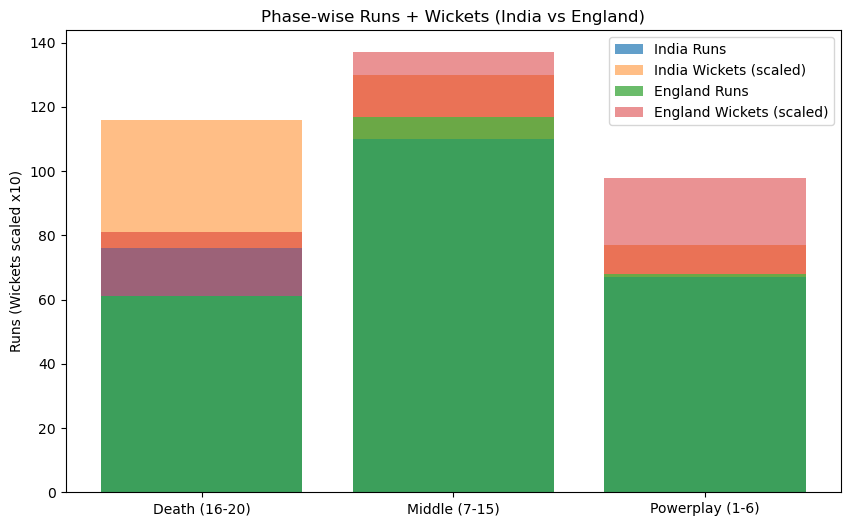

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Load phase data
phases = pd.read_csv("pbi_phases_1512772.csv")

# Prepare data
phase_summary = phases[["batting_team","phase","runs","wickets"]]

# Plot stacked bars
fig, ax = plt.subplots(figsize=(10,6))

# Create stacked bars for each team
for i, team in enumerate(phase_summary["batting_team"].unique()):
    team_data = phase_summary[phase_summary["batting_team"]==team]
    ax.bar(team_data["phase"], team_data["runs"], label=f"{team} Runs", alpha=0.7)
    ax.bar(team_data["phase"], team_data["wickets"]*10, 
           label=f"{team} Wickets (scaled)", alpha=0.5, bottom=team_data["runs"])

ax.set_title("Phase-wise Runs + Wickets (India vs England)")
ax.set_ylabel("Runs (Wickets scaled x10)")
ax.legend()
plt.show()

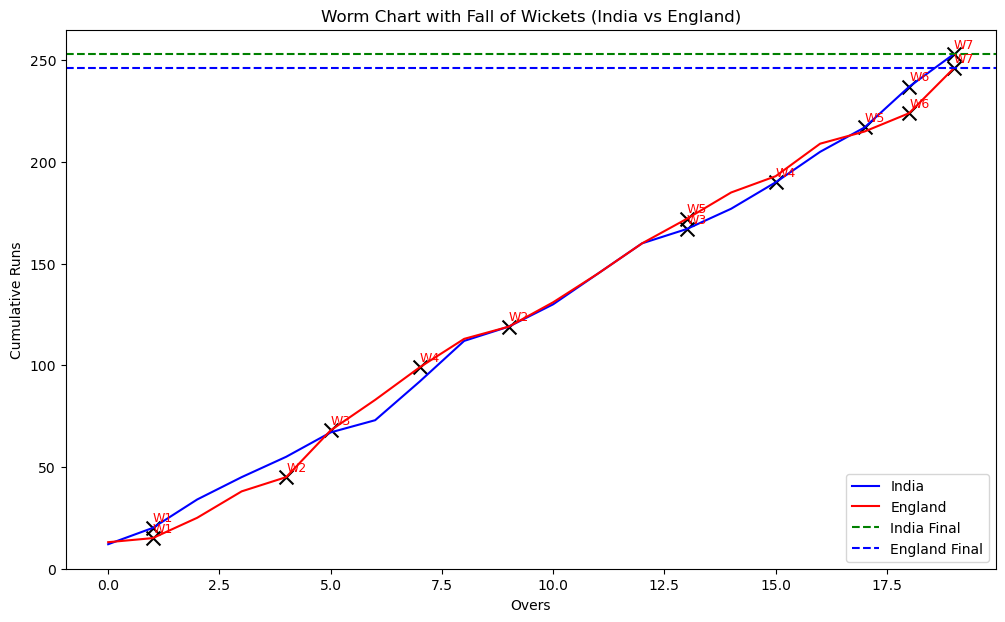

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Load overs and worm data
overs = pd.read_csv("pbi_overs_1512772.csv")
worm = pd.read_csv("pbi_worm_1512772.csv")

# Plot worm chart
plt.figure(figsize=(12,7))
plt.plot(worm["over"], worm["India"], label="India", color="blue")
plt.plot(worm["over"], worm["England"], label="England", color="red")

# Annotate fall of wickets
for idx, row in overs.iterrows():
    if row["wickets"] > 0:
        team = row["batting_team"]
        runs = row["cum_runs"]
        over = row["over"]
        plt.scatter(over, runs, color="black", marker="x", s=100)
        plt.text(over, runs+3, f"W{row['cum_wkts']}", fontsize=9, color="red")

# Final scores
plt.axhline(253, color="green", linestyle="--", label="India Final")
plt.axhline(246, color="blue", linestyle="--", label="England Final")

plt.title("Worm Chart with Fall of Wickets (India vs England)")
plt.xlabel("Overs")
plt.ylabel("Cumulative Runs")
plt.legend()
plt.show()

1️⃣ Win Probability Model

Input: pbi_overs.csv + pbi_worm.csv  

Task: Classification (Logistic Regression / XGBoost)

Output: Probability of winning at each over

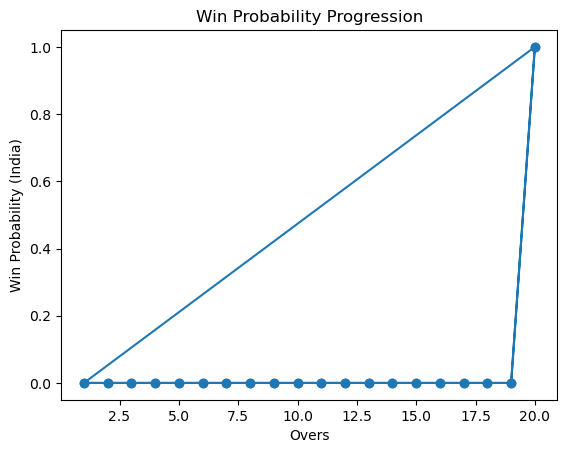

In [33]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
import matplotlib.pyplot as plt

# Load overs data
overs = pd.read_csv("pbi_overs_1512772.csv")

# Features: cumulative runs, wickets, overs, run rate
overs["run_rate"] = overs["runs"] / overs["legal_balls"] * 6
X = overs[["cum_runs","cum_wkts","overs_float_end","run_rate"]]
y = (overs["cum_runs"] >= 246).astype(int)  # 1 if India ahead of England final score

# Train model
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
model = GradientBoostingClassifier()
model.fit(X_train,y_train)

# Predict win probability
overs["win_prob"] = model.predict_proba(X)[:,1]

# Plot
plt.plot(overs["overs_float_end"], overs["win_prob"], marker="o")
plt.title("Win Probability Progression")
plt.xlabel("Overs")
plt.ylabel("Win Probability (India)")
plt.show()


2️⃣ Phase Forecasting

Input: pbi_phases.csv  

Task: Time series forecasting (Prophet / ARIMA / LSTM)

Output: Forecast curves for expected runs per phase

In [34]:
from statsmodels.tsa.arima.model import ARIMA

phases = pd.read_csv("pbi_phases_1512772.csv")
india_phase = phases[phases["batting_team"]=="India"]["runs"]

# ARIMA forecast
model = ARIMA(india_phase, order=(1,1,1))
fit = model.fit()
forecast = fit.forecast(steps=3)

print("Forecasted runs for next phases:", forecast)


C:\Users\bhara\coding\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


Forecasted runs for next phases: 3    106.699843
4     67.476263
5    106.229294
Name: predicted_mean, dtype: float64


3️⃣ Player Matchup Prediction

Input: pbi_matchups.csv  

Task: Recommendation / supervised learning

Output: Matrix of favorable/unfavorable duels

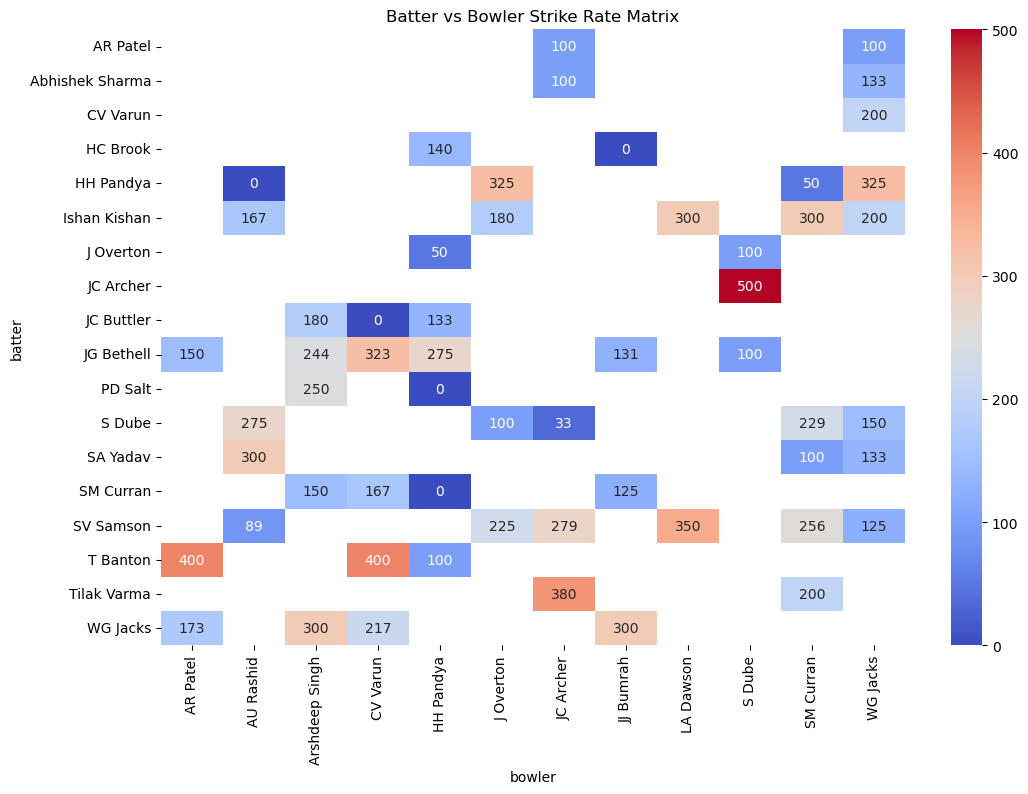

In [35]:
import seaborn as sns

matchups = pd.read_csv("pbi_matchups_1512772.csv")
pivot = matchups.pivot_table(index="batter", columns="bowler", values="sr", aggfunc="mean")

plt.figure(figsize=(12,8))
sns.heatmap(pivot, cmap="coolwarm", annot=True, fmt=".0f")
plt.title("Batter vs Bowler Strike Rate Matrix")
plt.show()


4️⃣ Bowler Economy & Wicket Forecast

Input: pbi_bowlers.csv  

Task: Regression (Random Forest / Linear Regression)

Output: Predicted economy & wickets in phases

In [36]:
from sklearn.ensemble import RandomForestRegressor

bowlers = pd.read_csv("pbi_bowlers_1512772.csv")

X = bowlers[["overs","runs_conceded"]]
y = bowlers["wickets"]

model = RandomForestRegressor()
model.fit(X,y)

bowlers["predicted_wkts"] = model.predict(X)
print(bowlers[["bowler","wickets","predicted_wkts"]])

            bowler  wickets  predicted_wkts
0         AR Patel        1            0.90
1   Arshdeep Singh        1            1.16
2         CV Varun        1            1.00
3        HH Pandya        2            1.85
4        JJ Bumrah        1            0.96
5           S Dube        1            0.73
6        AU Rashid        2            2.18
7        J Overton        0            0.46
8        JC Archer        1            1.00
9        LA Dawson        0            0.24
10       SM Curran        1            1.00
11        WG Jacks        3            2.52


5️⃣ Momentum Prediction

Input: pbi_worm.csv  

Task: Sequence models (RNN/LSTM)

Output: Forecast next 2–3 overs’ run progression

Forecasted runs per over (India): [19.00396948 19.00396948 19.00396948]


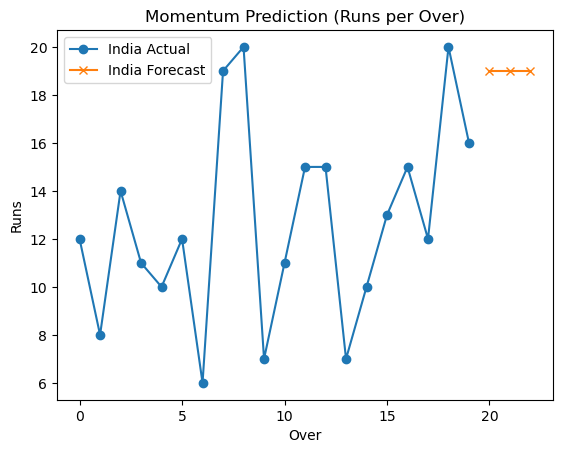

In [39]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.ensemble import GradientBoostingRegressor
overs = pd.read_csv("pbi_overs_1512772.csv")

# Use per-over runs instead of cumulative
india_runs = overs[overs["batting_team"]=="India"]["runs"].values
eng_runs = overs[overs["batting_team"]=="England"]["runs"].values

# Features: over number, wickets lost
X = overs[["over","wickets"]]
y = overs["runs"]

# Train regression model
model = GradientBoostingRegressor()
model.fit(X,y)

# Forecast next 3 overs for India
future_overs = pd.DataFrame({"over":[20,21,22],"wickets":[7,7,7]})
pred_runs = model.predict(future_overs)

# Clip predictions to cricket limits
pred_runs = np.clip(pred_runs,0,36)

print("Forecasted runs per over (India):", pred_runs)

# Plot actual vs forecast
plt.plot(range(len(india_runs)), india_runs, label="India Actual", marker="o")
plt.plot(range(len(india_runs), len(india_runs)+3), pred_runs, label="India Forecast", marker="x")
plt.title("Momentum Prediction (Runs per Over)")
plt.xlabel("Over")
plt.ylabel("Runs")
plt.legend()
plt.show()


Analytical Impact
Win Probability → Real‑time predictor like CricViz.

Phase Forecasting → Expected vs actual runs per phase.

Matchups → Pre‑match duel matrix (Samson vs Archer, Bethell vs Varun).

Bowler Forecast → Predicted economy/wickets for death overs.

Momentum Prediction → Worm chart overlay forecasting next overs.

In [41]:
## Phase Forecasting (LSTM/Transformer)


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

phases = pd.read_csv("pbi_phases_1512772.csv")
india_phase = phases[phases["batting_team"]=="India"]["runs"].values

# Sequence prep
X, y = [], []
for i in range(len(india_phase)-2):
    X.append(india_phase[i:i+2])
    y.append(india_phase[i+2])
X, y = np.array(X), np.array(y)

X = X.reshape((X.shape[0], X.shape[1], 1))

# LSTM model
model = Sequential([
    LSTM(50, activation='relu', input_shape=(2,1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X,y,epochs=100,verbose=0)

forecast = model.predict(X[-1].reshape(1,2,1))
print("Forecasted next phase runs:", forecast)


C:\Users\bhara\coding\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
Forecasted next phase runs: [[64.96137]]


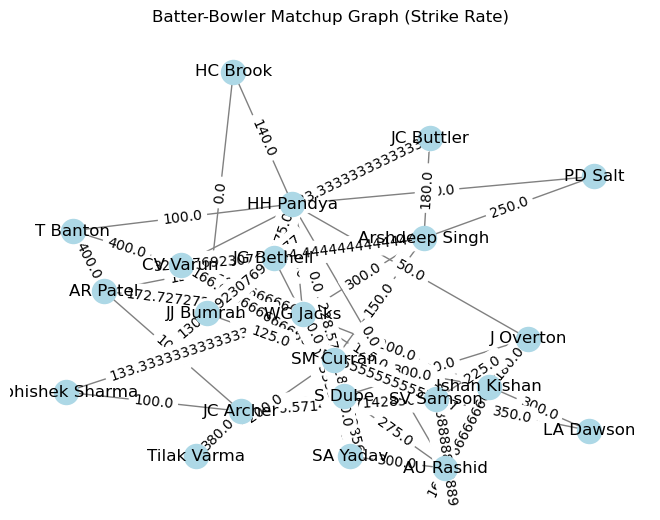

In [52]:
## Player Matchup Prediction (Graph Neural Network)

import networkx as nx
import matplotlib.pyplot as plt

matchups = pd.read_csv("pbi_matchups_1512772.csv")

# Build bipartite graph: batters vs bowlers
G = nx.Graph()
for _, row in matchups.iterrows():
    G.add_edge(row["batter"], row["bowler"], weight=row["sr"])

# Visualize
pos = nx.spring_layout(G, k=2)
nx.draw(G, pos, with_labels=True, node_color="lightblue", edge_color="gray")
labels = nx.get_edge_attributes(G,'weight')
nx.draw_networkx_edge_labels(G,pos,edge_labels=labels)
plt.title("Batter-Bowler Matchup Graph (Strike Rate)")
plt.show()

In [43]:
## Bowler Economy & Wicket Forecast (Bayesian Update)

bowlers = pd.read_csv("pbi_bowlers_1512772.csv")

# Prior expectation
prior_mean = bowlers["wickets"].mean()
prior_var = bowlers["wickets"].var()

# Bayesian update per bowler
bowlers["posterior_mean"] = (prior_mean + bowlers["wickets"]) / 2
bowlers["posterior_var"] = (prior_var + (bowlers["wickets"]-prior_mean)**2) / 2

print(bowlers[["bowler","wickets","posterior_mean"]])

            bowler  wickets  posterior_mean
0         AR Patel        1        1.083333
1   Arshdeep Singh        1        1.083333
2         CV Varun        1        1.083333
3        HH Pandya        2        1.583333
4        JJ Bumrah        1        1.083333
5           S Dube        1        1.083333
6        AU Rashid        2        1.583333
7        J Overton        0        0.583333
8        JC Archer        1        1.083333
9        LA Dawson        0        0.583333
10       SM Curran        1        1.083333
11        WG Jacks        3        2.083333
